# Locust Load Test - Latency Spike Analysis

This notebook helps investigate latency spikes in load test runs.

## Setup

Update these variables with your run details:

In [1]:
import sqlite3
import pandas as pd
from datetime import datetime, timedelta

# Configuration
DB_PATH = "../query_response_times.db"
RUN_ID = "9e5f2898-cd96-4eb9-84d6-8f5ca9782a65"  # Update with your run ID

# Spike time window (in UTC)
SPIKE_START = "2026-03-31T18:17:00+00:00"  # 11:17 AM PDT
SPIKE_END = "2026-03-31T18:18:00+00:00"    # 11:18 AM PDT

# Connect to database
conn = sqlite3.connect(DB_PATH)

print(f"Analyzing run: {RUN_ID}")
print(f"Spike window: {SPIKE_START} to {SPIKE_END}")

Analyzing run: 9e5f2898-cd96-4eb9-84d6-8f5ca9782a65
Spike window: 2026-03-31T18:17:00+00:00 to 2026-03-31T18:18:00+00:00


## 1. Get Overview of Run

Check the timestamp range and total requests in the run:

In [2]:
query = """
SELECT 
  MIN(timestamp) as earliest,
  MAX(timestamp) as latest,
  COUNT(*) as total_records,
  SUM(CASE WHEN success = 0 THEN 1 ELSE 0 END) as failures
FROM response_times
WHERE run_id = ?;
"""

df = pd.read_sql_query(query, conn, params=[RUN_ID])
df

,earliest,latest,total_records,failures
0,2026-03-31T17:56:20.422123+00:00,2026-03-31T18:26:42.968407+00:00,34868,67


## 2. Latency Over Time (by minute)

View average latency per minute to identify spike periods:

In [3]:
query = """
SELECT 
  strftime('%H:%M', timestamp) as time,
  COUNT(*) as count,
  ROUND(AVG(response_time_ms), 2) as avg_ms,
  ROUND(MIN(response_time_ms), 2) as min_ms,
  ROUND(MAX(response_time_ms), 2) as max_ms,
  SUM(CASE WHEN success = 0 THEN 1 ELSE 0 END) as failures
FROM response_times
WHERE run_id = ?
GROUP BY strftime('%H:%M', timestamp)
ORDER BY time;
"""

df_timeline = pd.read_sql_query(query, conn, params=[RUN_ID])
df_timeline

,time,count,avg_ms,min_ms,max_ms,failures
0,17:56,67,40.91,7.03,1541.52,67
1,17:57,394,354.90,8.11,1657.43,0
2,17:58,1438,487.95,5.79,3845.60,0
3,17:59,1475,598.10,5.36,6247.54,0
4,18:00,1427,647.54,5.05,8468.25,0
5,18:01,1446,627.07,4.37,10503.19,0
6,18:02,1457,603.61,4.20,13801.26,0
7,18:03,1341,857.38,4.89,20129.79,0
8,18:04,1205,1041.62,6.66,27532.57,0
9,18:05,1332,945.52,4.80,30002.38,0


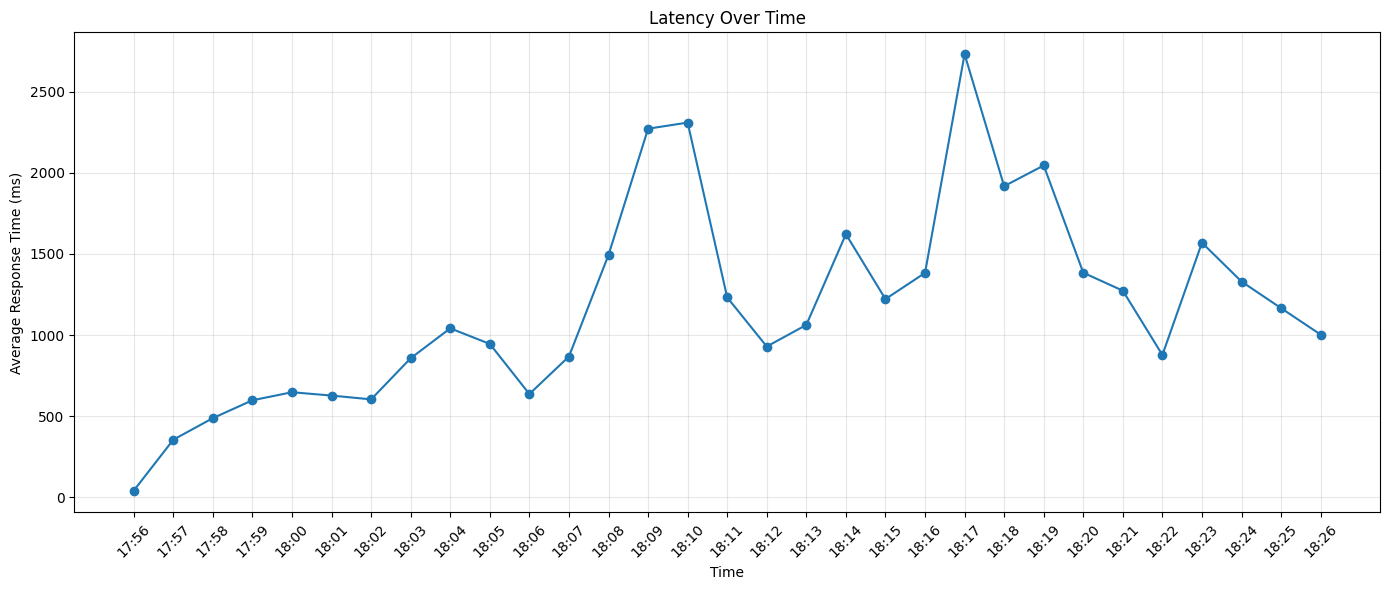

In [4]:
# Plot latency over time
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(df_timeline['time'], df_timeline['avg_ms'], marker='o')
plt.xlabel('Time')
plt.ylabel('Average Response Time (ms)')
plt.title('Latency Over Time')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Compare Spike vs Baseline Performance by Query

Find which queries had the biggest slowdown during the spike:

In [5]:
# Get spike period stats
spike_query = """
SELECT 
  query_name,
  COUNT(*) as spike_count,
  AVG(response_time_ms) as spike_avg,
  MAX(response_time_ms) as spike_max,
  MIN(response_time_ms) as spike_min
FROM response_times
WHERE run_id = ?
  AND timestamp >= ?
  AND timestamp <= ?
GROUP BY query_name;
"""

# Get baseline stats (everything outside spike window)
baseline_query = """
SELECT 
  query_name,
  COUNT(*) as baseline_count,
  AVG(response_time_ms) as baseline_avg,
  MAX(response_time_ms) as baseline_max,
  MIN(response_time_ms) as baseline_min
FROM response_times
WHERE run_id = ?
  AND (timestamp < ? OR timestamp > ?)
GROUP BY query_name;
"""

df_spike = pd.read_sql_query(spike_query, conn, params=[RUN_ID, SPIKE_START, SPIKE_END])
df_baseline = pd.read_sql_query(baseline_query, conn, params=[RUN_ID, SPIKE_START, SPIKE_END])

# Merge and calculate slowdown ratio
df_comparison = pd.merge(df_spike, df_baseline, on='query_name', suffixes=('_spike', '_baseline'))

# Only include queries with sufficient baseline data
df_comparison = df_comparison[df_comparison['baseline_count'] > 10]

# Calculate slowdown ratio
df_comparison['slowdown_ratio'] = df_comparison['spike_avg'] / df_comparison['baseline_avg']

# Round for readability
df_comparison['spike_avg'] = df_comparison['spike_avg'].round(2)
df_comparison['baseline_avg'] = df_comparison['baseline_avg'].round(2)
df_comparison['slowdown_ratio'] = df_comparison['slowdown_ratio'].round(2)
df_comparison['spike_max'] = df_comparison['spike_max'].round(2)

# Sort by slowdown ratio
df_comparison = df_comparison.sort_values('slowdown_ratio', ascending=False)

# Display top 20
df_comparison[['query_name', 'spike_avg', 'baseline_avg', 'slowdown_ratio', 'spike_count', 'spike_max']].head(20)

,query_name,spike_avg,baseline_avg,slowdown_ratio,spike_count,spike_max
44,range_field_conjunction_small_range_small_term...,1235.00,97.00,12.73,9,3252.55
48,range_numeric,1130.61,98.54,11.47,9,3289.08
69,term_headless,900.56,86.01,10.47,10,2066.19
42,range_field_conjunction_small_range_big_term_q...,771.24,76.58,10.07,11,2308.03
54,scroll,854.58,87.08,9.81,3,2494.78
68,term,835.92,85.55,9.77,9,2760.41
36,range,1007.89,105.09,9.59,8,3342.55
0,asc_sort_timestamp,690.13,72.10,9.57,12,3338.97
6,asc_sort_with_after_timestamp,918.48,103.20,8.90,13,2492.24
43,range_field_conjunction_small_range_small_term...,729.60,83.33,8.76,16,2922.12


In [6]:
# Show queries with highest absolute spike latency
df_comparison.sort_values('spike_avg', ascending=False)[['query_name', 'spike_avg', 'baseline_avg', 'slowdown_ratio', 'spike_max']].head(20)

,query_name,spike_avg,baseline_avg,slowdown_ratio,spike_max
29,multi_terms_keyword,79616.66,33790.89,2.36,81710.91
63,sort_numeric_asc_with_match_headless,5611.74,2261.96,2.48,10151.05
51,range_with_asc_sort_headless,5509.20,2279.77,2.42,9209.29
61,sort_numeric_asc_headless,5453.75,2258.80,2.41,8590.11
18,desc_sort_timestamp_headless,5326.68,2297.89,2.32,9764.31
20,desc_sort_timestamp_no_can_match_shortcut_head...,5202.25,2172.09,2.40,7367.84
53,range_with_desc_sort_headless,5108.31,2306.66,2.21,9406.04
7,asc_sort_with_after_timestamp_headless,5106.85,2278.75,2.24,8081.67
55,scroll_headless,5029.79,1839.47,2.73,9487.10
2,asc_sort_timestamp_can_match_shortcut_headless,5014.02,2244.08,2.23,10247.72


## 4. Analyze Specific Time Window

Look at the slowest queries during a specific short window (e.g., P50 spike moment):

In [7]:
# Adjust this for your specific spike moment
EXACT_SPIKE_START = "2026-03-31T18:09:30+00:00"  # 11:09:30 PDT
EXACT_SPIKE_END = "2026-03-31T18:09:40+00:00"    # 11:09:40 PDT

query = """
SELECT 
  query_name,
  strftime('%H:%M:%S', timestamp) as time,
  ROUND(response_time_ms, 2) as ms,
  success
FROM response_times
WHERE run_id = ?
  AND timestamp >= ?
  AND timestamp <= ?
ORDER BY response_time_ms DESC
LIMIT 30;
"""

df_moment = pd.read_sql_query(query, conn, params=[RUN_ID, EXACT_SPIKE_START, EXACT_SPIKE_END])
df_moment

,query_name,time,ms,success
0,keyword_in_range_headless,18:09:30,5845.50,1
1,desc_sort_timestamp_headless,18:09:30,5632.38,1
2,keyword_in_range_headless,18:09:31,5444.60,1
3,keyword_in_range_headless,18:09:30,5367.17,1
4,range_with_asc_sort_headless,18:09:31,5320.31,1
5,desc_sort_timestamp_can_match_shortcut_headless,18:09:31,5274.55,1
6,asc_sort_with_after_timestamp_headless,18:09:31,4831.03,1
7,range_with_asc_sort_headless,18:09:38,4779.50,1
8,desc_sort_timestamp_headless,18:09:34,4743.52,1
9,asc_sort_timestamp_no_can_match_shortcut_headless,18:09:33,4715.91,1


## 5. Deep Dive on Specific Query

Analyze how a specific problematic query performed over time:

In [8]:
# Update this with the query you want to investigate
QUERY_NAME = "multi_terms_keyword"

query = """
SELECT 
  strftime('%H:%M', timestamp) as time,
  COUNT(*) as count,
  ROUND(AVG(response_time_ms), 2) as avg_ms,
  ROUND(MIN(response_time_ms), 2) as min_ms,
  ROUND(MAX(response_time_ms), 2) as max_ms,
  SUM(CASE WHEN success = 0 THEN 1 ELSE 0 END) as failures
FROM response_times
WHERE run_id = ?
  AND query_name = ?
GROUP BY strftime('%H:%M', timestamp)
ORDER BY time;
"""

df_query = pd.read_sql_query(query, conn, params=[RUN_ID, QUERY_NAME])
print(f"Performance over time for: {QUERY_NAME}")
df_query

Performance over time for: multi_terms_keyword


,time,count,avg_ms,min_ms,max_ms,failures
0,17:56,1,8.38,8.38,8.38,1
1,17:57,7,669.85,555.41,850.44,0
2,17:58,19,2105.26,896.32,3845.60,0
3,17:59,20,4713.18,3259.91,6247.54,0
4,18:00,22,7104.21,5132.57,8468.25,0
5,18:01,13,9632.60,8593.70,10503.19,0
6,18:02,9,12523.67,10758.37,13801.26,0
7,18:03,17,19578.47,17638.21,20129.79,0
8,18:04,15,25114.54,22958.75,27532.57,0
9,18:05,24,18382.83,3932.76,30002.38,0


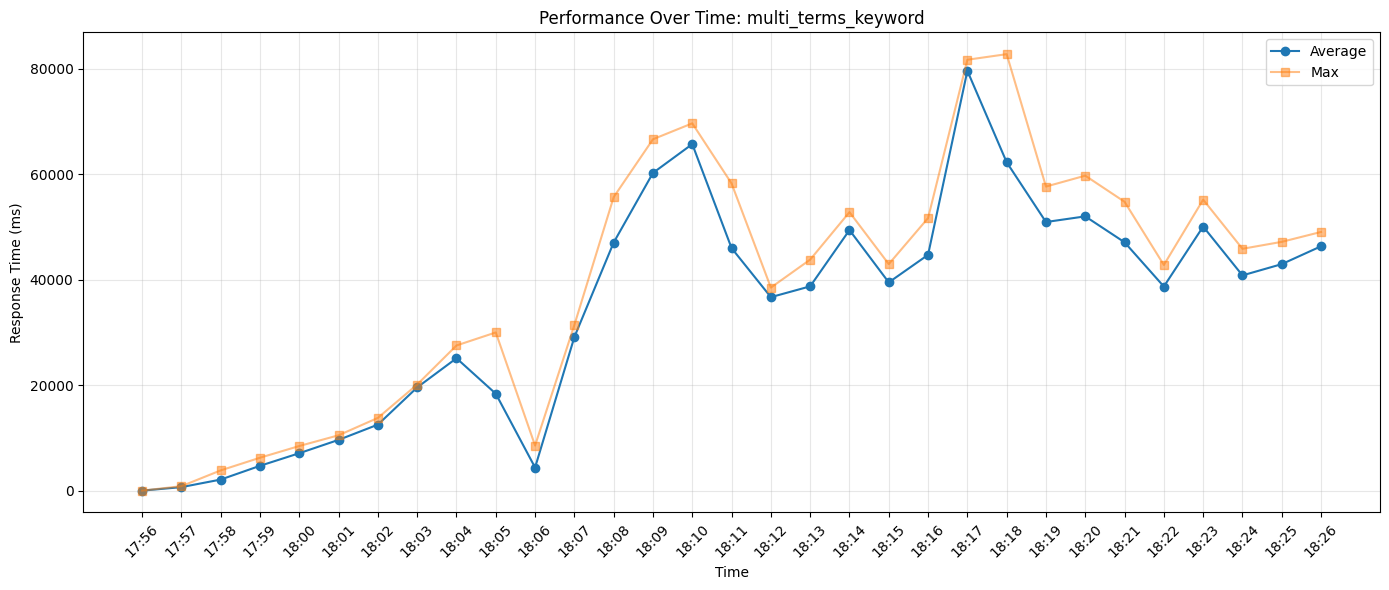

In [9]:
# Plot specific query performance
plt.figure(figsize=(14, 6))
plt.plot(df_query['time'], df_query['avg_ms'], marker='o', label='Average')
plt.plot(df_query['time'], df_query['max_ms'], marker='s', alpha=0.5, label='Max')
plt.xlabel('Time')
plt.ylabel('Response Time (ms)')
plt.title(f'Performance Over Time: {QUERY_NAME}')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Pattern Analysis

Look for patterns in which types of queries were affected:

In [10]:
# Add pattern matching (e.g., headless vs non-headless)
df_comparison['is_headless'] = df_comparison['query_name'].str.contains('headless')

print("Average slowdown by query type:")
df_comparison.groupby('is_headless')[['slowdown_ratio', 'spike_avg', 'baseline_avg']].mean().round(2)

Average slowdown by query type:


,slowdown_ratio,spike_avg,baseline_avg
is_headless,,,
False,5.85,2599.10,942.18
True,3.72,3183.52,1386.84


In [11]:
# Extract query patterns
def extract_pattern(name):
    if 'sort' in name:
        return 'sort'
    elif 'range' in name:
        return 'range'
    elif 'terms' in name:
        return 'terms'
    elif 'histogram' in name:
        return 'histogram'
    elif 'query_string' in name:
        return 'query_string'
    else:
        return 'other'

df_comparison['pattern'] = df_comparison['query_name'].apply(extract_pattern)

print("\nAverage slowdown by query pattern:")
df_comparison.groupby('pattern')[['slowdown_ratio', 'spike_avg', 'baseline_avg', 'spike_count']].mean().round(2).sort_values('slowdown_ratio', ascending=False)


Average slowdown by query pattern:


,slowdown_ratio,spike_avg,baseline_avg,spike_count
pattern,,,,
histogram,6.60,708.48,107.79,8.33
other,6.24,1991.90,664.04,9.17
range,5.98,1233.79,391.82,10.12
query_string,4.89,731.93,154.80,9.00
terms,4.79,7892.40,3203.15,10.09
sort,4.04,2589.93,1116.60,10.06


## 7. Export Results

Save comparison results for further analysis:

In [12]:
# Save to CSV
output_file = f"spike_analysis_{RUN_ID[:8]}.csv"
df_comparison.to_csv(output_file, index=False)
print(f"Results saved to: {output_file}")

Results saved to: spike_analysis_9e5f2898.csv


In [13]:
# Clean up
conn.close()